# Quantitative Risk & Derivative Pricing
### Portfolio Risk Modelling, VaR Backtesting, Option Pricing and Hedging

**Notebook structure**
- Task 1 - Asset Selection & Data Download
- Task 2 - Data Cleaning and Preprocessing
- Task 3 - Volatility Modeling and Forecasting
- Task 4 - Value at Risk (VaR) Estimation
- Task 5 - Backtesting and Model Validation (static + rolling window + breach plots)
- Task 6 - Option Pricing and Greek Sensitivities
- Task 7 - Hedging Strategy Implementation (delta-neutral + SBI option overlay)

**Corrections applied to the original code**
- **FIX 1:** yfinance returns columns in alphabetical order, so columns are re-ordered to the ticker order *before* names are assigned (asset labels and the delta vector now match).
- **FIX 2:** the delta-neutral rebalancing used the same day's return to choose weights (look-ahead bias). Weights for day *t* now use only information up to day *t-1*.

### Task 1 - Asset Selection & Data Download
Financial Assets for the portfolio:
- HDFC Asset Management Company (Large Cap)
- NIFTY 50 (Index)
- EUR/INR (FX Rate)
- Macpower CNC Machines (Small Cap)
- Gold (Commodity)

In [49]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns
plt.style.use("default")
import warnings
warnings.filterwarnings("ignore")

In [50]:
# Define tickers
tickers = {
    "HDFC AMC (Large Cap)": "HDFCAMC.NS",
    "Macpower CNC (Small Cap)": "MACPOWER.NS",
    "NIFTY 50 (Index)": "^NSEI",
    "EUR/INR (FX Rate)": "EURINR=X",
    "Gold (Commodity)": "GC=F"
}

# Define date range
start_date = "2019-06-16" # nana's birthday
end_date = "2024-06-26" # dada's birthday

# Download adjusted close prices (USD/INR pulled alongside, just to convert Gold to INR/10g)
raw = yf.download(list(tickers.values()) + ["USDINR=X"], start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
raw = raw[list(tickers.values()) + ["USDINR=X"]]  # force intended column order - yfinance can return multi-ticker columns alphabetically, not in request order
raw.columns = list(tickers.keys()) + ["USD/INR"]

# Gold quoted by yfinance is USD per troy ounce; convert to INR per 10 grams,
# which is how gold is actually quoted in India (1 troy oz = 31.1034768 g)
raw["Gold (Commodity)"] = raw["Gold (Commodity)"] * raw["USD/INR"] / 31.1034768 * 10

data = raw[list(tickers.keys())]
data

[*********************100%***********************]  6 of 6 completed


,HDFC AMC (Large Cap),Macpower CNC (Small Cap),NIFTY 50 (Index),EUR/INR (FX Rate),Gold (Commodity)
Date,,,,,
2019-06-17,845.549011,116.606445,11672.150391,78.195999,30029.364816
2019-06-18,791.904602,117.180382,11691.500000,78.297997,30354.643471
2019-06-19,789.168762,117.180382,11691.450195,77.869003,30159.334623
2019-06-20,797.201294,114.788940,11831.750000,78.175003,31289.726598
2019-06-21,819.547546,128.180984,11724.099609,78.445999,31323.453489
...,...,...,...,...,...
2024-06-19,1873.254761,1381.594604,23516.000000,89.454002,NaN
2024-06-20,1869.364380,1449.147339,23567.000000,89.611000,63536.562848
2024-06-21,1879.258301,1399.180176,23501.099609,89.397003,62659.248225


### Task 2 - Data Cleaning and Preprocessing
- Using Forward Fill (ffill) for missing values
- Calculate log returns
- Visualization using Line Charts and Histograms

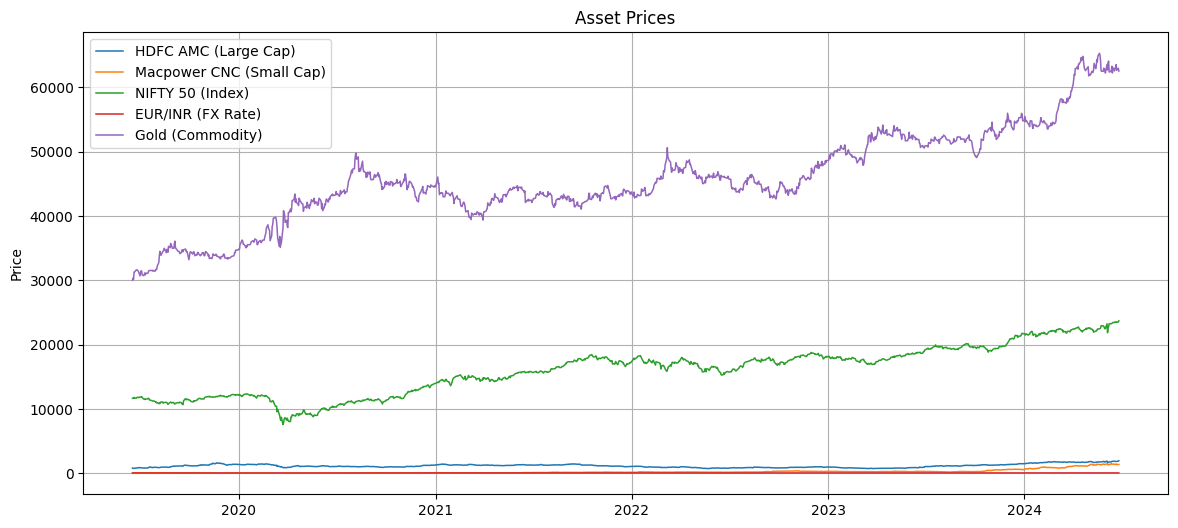

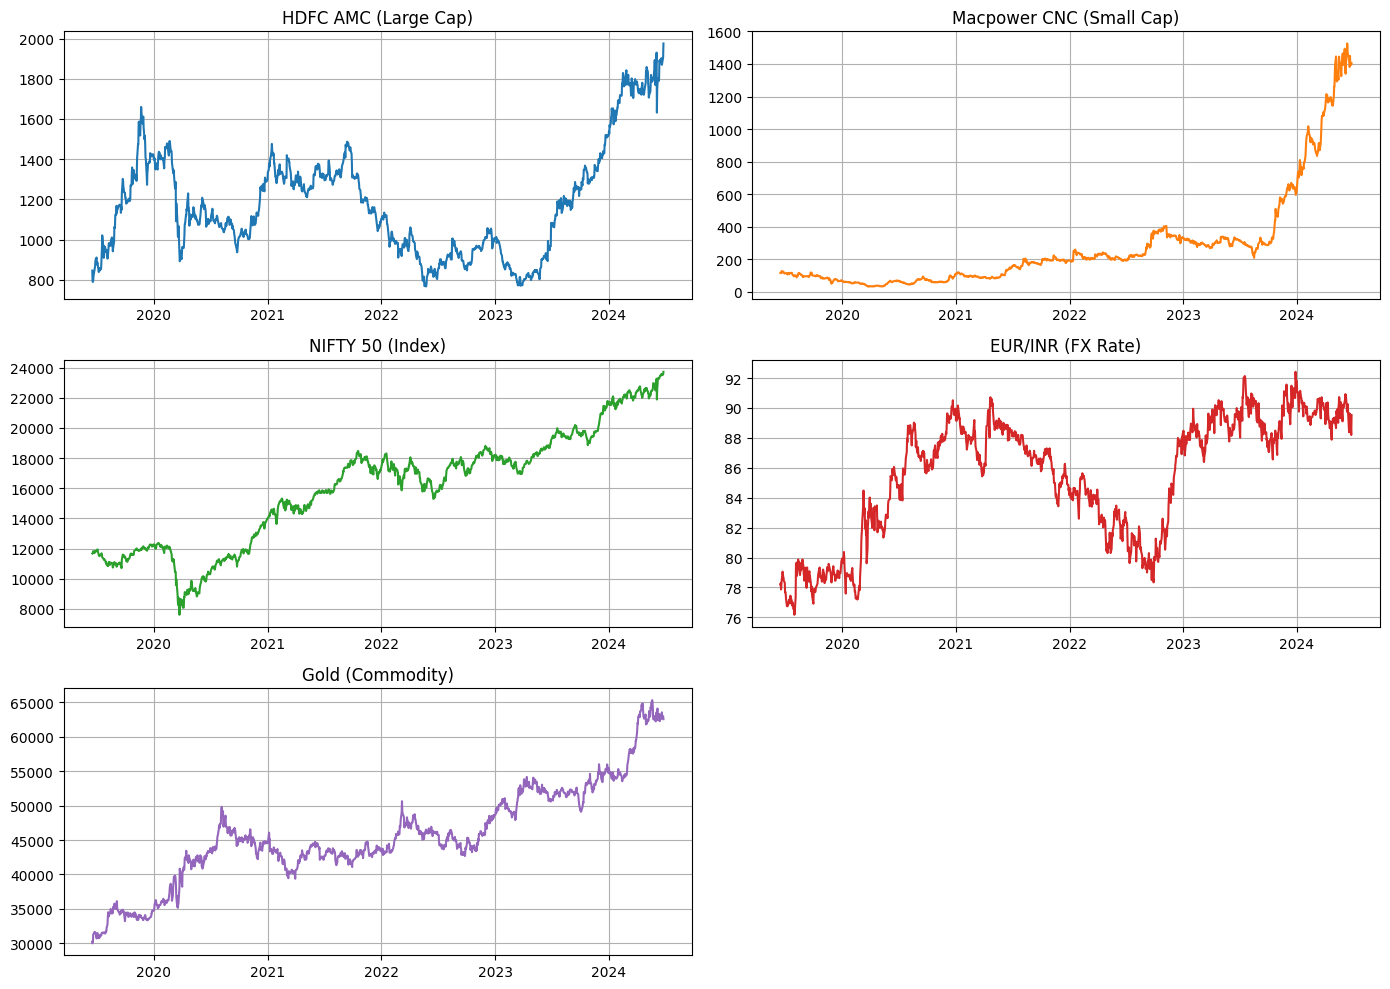

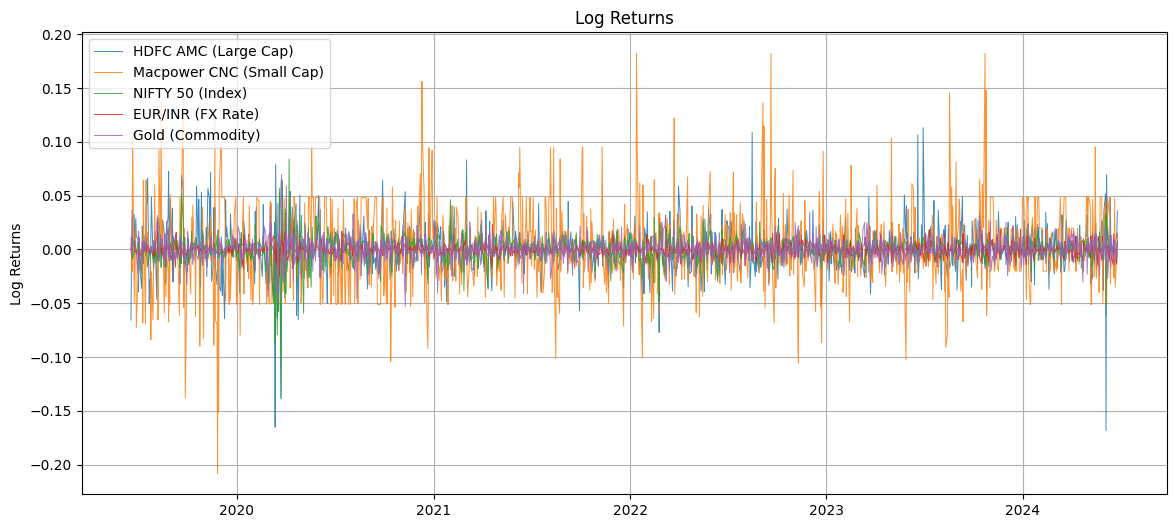

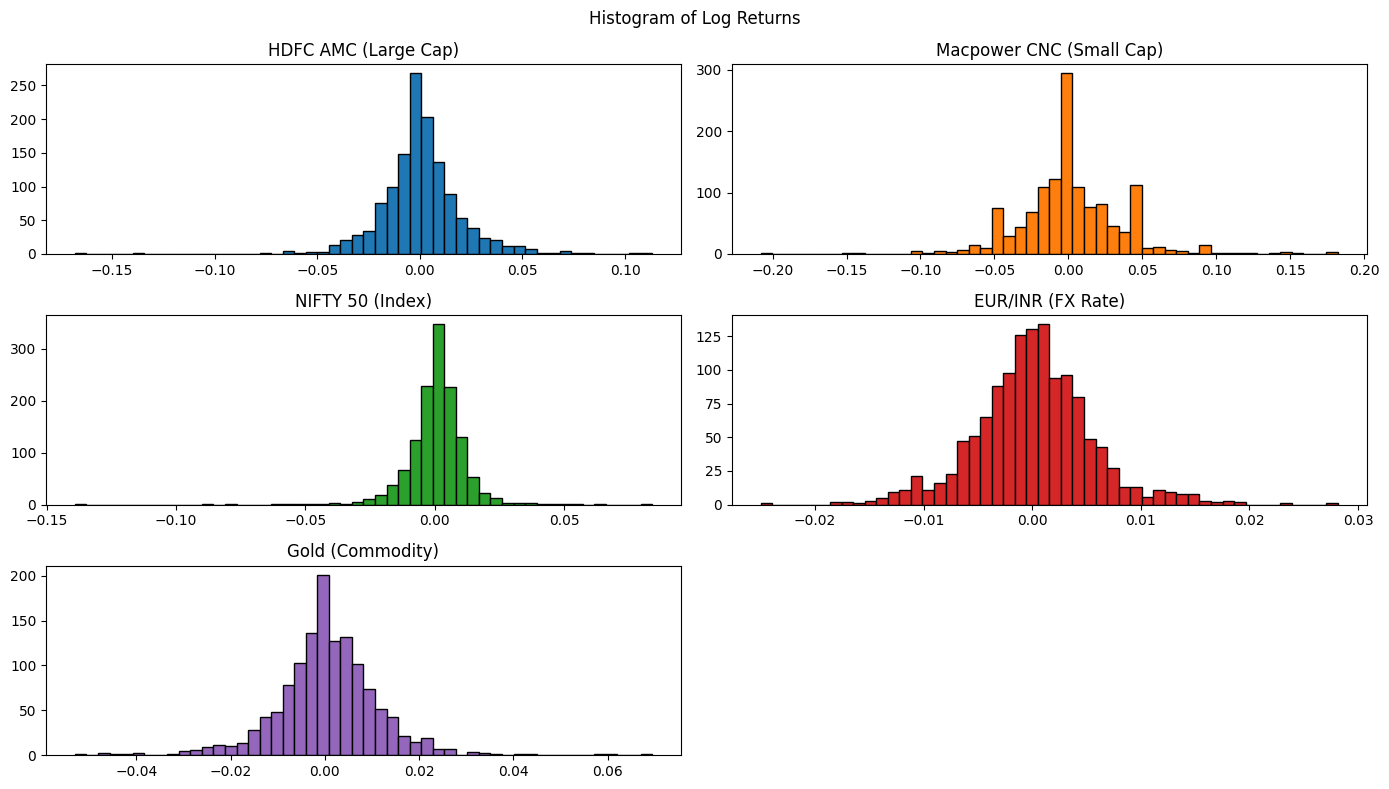

In [51]:
# Forward fill to handle missing values
data_ffill = data.ffill().dropna()

# Calculate daily log returns
returns = np.log(data_ffill / data_ffill.shift(1)).dropna()

# Fixed color per asset, reused across every chart below so the same asset
# always has the same color (tab10 palette - 5 clearly distinguishable colors)
asset_colors = dict(zip(data_ffill.columns, plt.cm.tab10.colors[:len(data_ffill.columns)]))

# Plot price history (raw values, native units)
fig, ax = plt.subplots(figsize=(14, 6))
for col in data_ffill.columns:
    ax.plot(data_ffill.index, data_ffill[col], label=col, color=asset_colors[col], lw=1.1)
ax.set_title("Asset Prices")
ax.set_ylabel("Price")
ax.grid(True)
ax.legend(loc="upper left")
plt.show()

# Extra graph: each asset in its own panel, in native units (NIFTY ~20,000
# points dwarfs EUR/INR ~90 on the combined chart above, so this makes the
# smaller-scale series readable too)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), data_ffill.columns):
    ax.plot(data_ffill.index, data_ffill[col], color=asset_colors[col])
    ax.set_title(col)
    ax.grid(True)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

# Plot return history
fig, ax = plt.subplots(figsize=(14, 6))
for col in returns.columns:
    ax.plot(returns.index, returns[col], label=col, color=asset_colors[col], lw=0.7, alpha=0.85)
ax.set_title("Log Returns")
ax.set_ylabel("Log Returns")
ax.grid(True)
ax.legend(loc="upper left")
plt.show()

# Plot histograms of returns
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), returns.columns):
    ax.hist(returns[col], bins=50, edgecolor='black', color=asset_colors[col])
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.suptitle("Histogram of Log Returns")
plt.tight_layout()
plt.show()

In [52]:
# merge all the returns into a single DataFrame
returns_df = pd.DataFrame(returns)
returns_df.columns = tickers.keys()
from scipy.stats import skew, kurtosis

data = returns_df.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data

,Date,HDFC AMC (Large Cap),Macpower CNC (Small Cap),NIFTY 50 (Index),EUR/INR (FX Rate),Gold (Commodity)
0,2019-06-18,-0.065545,0.004910,0.001656,0.001304,0.010774
1,2019-06-19,-0.003461,0.000000,-0.000004,-0.005494,-0.006455
2,2019-06-20,0.010127,-0.020619,0.011929,0.003922,0.036795
3,2019-06-21,0.027645,0.110348,-0.009140,0.003461,0.001077
4,2019-06-24,0.032372,-0.049723,-0.002088,0.007771,0.009865
...,...,...,...,...,...,...
1308,2024-06-19,-0.015456,-0.026474,-0.001780,-0.001966,0.000000
1309,2024-06-20,-0.002079,0.047737,0.002166,0.001754,0.008287
1310,2024-06-21,0.005279,-0.035089,-0.002800,-0.002391,-0.013904
1311,2024-06-24,0.014236,-0.002995,0.001563,-0.013577,0.005179


In [53]:
# Task 2 : Printing the summary statistics upto 2 decimal points
for col in returns_df.columns:
    print(f"Summary statistics for {col}:")
    print(f"Mean: {returns_df[col].mean():.5f}")
    print(f"Standard Deviation: {returns_df[col].std():.2f}")
    print(f"Skewness: {skew(returns_df[col]):.2f}")
    print(f"Kurtosis: {kurtosis(returns_df[col]):.2f}")
    print("-" * 50)

Summary statistics for HDFC AMC (Large Cap):
Mean: 0.00065
Standard Deviation: 0.02
Skewness: -0.47
Kurtosis: 10.18
--------------------------------------------------
Summary statistics for Macpower CNC (Small Cap):
Mean: 0.00190
Standard Deviation: 0.04
Skewness: 0.43
Kurtosis: 3.70
--------------------------------------------------
Summary statistics for NIFTY 50 (Index):
Mean: 0.00054
Standard Deviation: 0.01
Skewness: -1.69
Kurtosis: 22.56
--------------------------------------------------
Summary statistics for EUR/INR (FX Rate):
Mean: 0.00010
Standard Deviation: 0.01
Skewness: 0.19
Kurtosis: 1.84
--------------------------------------------------
Summary statistics for Gold (Commodity):
Mean: 0.00056
Standard Deviation: 0.01
Skewness: 0.10
Kurtosis: 4.34
--------------------------------------------------


In [54]:
# Task 3 - Performing Volatility estimation using Historical Volatility Method and GARCH-type models
portfolio_weights = np.array([0.2] * len(returns_df.columns))  # Equal weights for each asset
portfolio_returns = returns_df.dot(portfolio_weights)
portfolio_returns_df = pd.DataFrame(portfolio_returns, columns=["Portfolio Returns"])

# print the mean std skewness and kurtosis of the portfolio returns
print(f"Summary statistics for the portfolio:")
print(f"Mean: {portfolio_returns_df['Portfolio Returns'].mean():.5f}")
print(f"Standard Deviation: {portfolio_returns_df['Portfolio Returns'].std():.5f}")
print(f"Skewness: {skew(portfolio_returns_df['Portfolio Returns']):.2f}")
print(f"Kurtosis: {kurtosis(portfolio_returns_df['Portfolio Returns']):.2f}")
print("-" * 50)

portfolio_returns_df

Summary statistics for the portfolio:
Mean: 0.00075
Standard Deviation: 0.01025
Skewness: -0.46
Kurtosis: 3.99
--------------------------------------------------


,Portfolio Returns
Date,
2019-06-18,-0.009380
2019-06-19,-0.003083
2019-06-20,0.008431
2019-06-21,0.026678
2019-06-24,-0.000361
...,...
2024-06-19,-0.009135
2024-06-20,0.011573
2024-06-21,-0.009781


### Task 3 - Volatility Modeling and Forecasting
- Finding the best ARIMA Model by comparing BIC scores
- Testing for Heteroskedasticity using GARCH models
- Forecasting volatility for 30 days
- Interpretation of the output

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=-8288.485, Time=0.14 sec
 ARIMA(1,0,0)(0,0,0)[0]             : BIC=-8285.862, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=-8285.428, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=-8282.914, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=-8288.294, Time=0.14 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.545 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1313
Model:                        SARIMAX   Log Likelihood                4147.833
Date:                Sat, 03 Oct 2026   AIC                          -8293.665
Time:                        20:50:32   BIC                          -8288.485
Sample:                             0   HQIC                         -8291.723
                               - 1313                                  

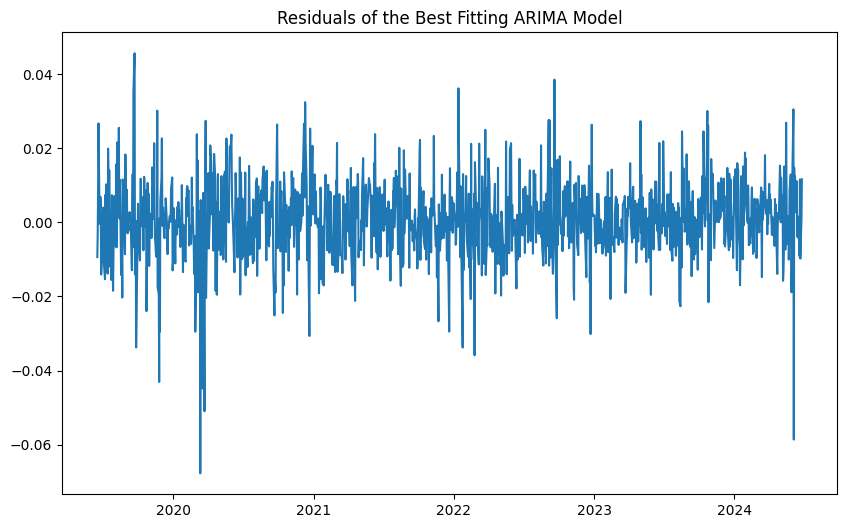

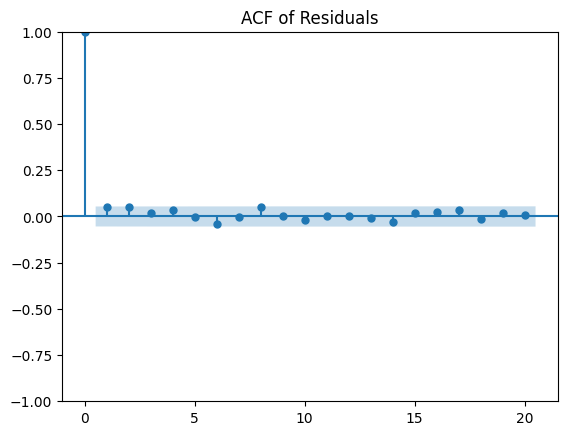

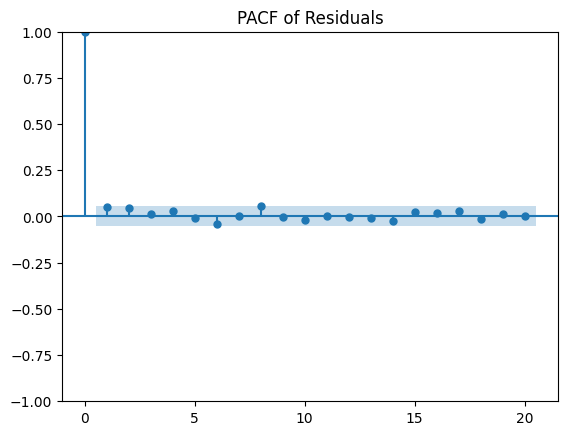

In [85]:
# Modeling the returns using ARIMA 
import pmdarima as pm

# Assuming 'data' and 'returns' are defined from the previous code
returns = portfolio_returns_df['Portfolio Returns'].dropna()

# Find best ARIMA model by AIC
arima_model = pm.auto_arima(returns, start_p=0, start_q=0,
                           max_p=5, max_q=5, m=1,
                           start_P=0, seasonal=False,information_criterion='bic',
                           d=None, D=0, trace=True,
                           error_action='ignore',  # we don't want to know if an order does not work
                           suppress_warnings=True,  # we don't want convergence warnings
                           stepwise=True)

# Print the model summary
print(arima_model.summary())

# Get the residuals
residuals = arima_model.resid()

# Analyze the residuals (e.g., plot them, check for autocorrelation)
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title("Residuals of the Best Fitting ARIMA Model")
plt.show()

# Further analysis on residuals (e.g., ACF, PACF plots)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()

plot_pacf(residuals, lags=20)
plt.title("PACF of Residuals")
plt.show()

In [56]:
# performing tests for checking for hetersoskedasticity
import statsmodels.api as sm

# Assuming 'residuals' from the ARIMA model is available
# Perform the Breusch-Pagan test for heteroskedasticity
bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, exog_het=sm.add_constant(np.arange(len(residuals))))

# Print the test results
print("\nBreusch-Pagan Test for Heteroskedasticity:")
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
for label, value in zip(labels, bp_test):
    print(f"{label}: {value}")

# Interpretation
alpha = 0.05  # Significance level
if bp_test[1] < alpha:
    print("Reject the null hypothesis. Heteroskedasticity is present in the residuals.")
else:
    print("Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.")


# Alternatively, you can use the Goldfeld-Quandt test
gq_test = sm.stats.diagnostic.het_goldfeldquandt(residuals, x=sm.add_constant(np.arange(len(residuals))))

print("\nGoldfeld-Quandt Test for Heteroskedasticity:")
print(f"F-statistic: {gq_test[0]}")
print(f"p-value: {gq_test[1]}")

if gq_test[1] < alpha:
  print("Reject the null hypothesis. Heteroskedasticity is present in the residuals.")
else:
  print("Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.")


Breusch-Pagan Test for Heteroskedasticity:
Lagrange multiplier statistic: 9.763486885083534
p-value: 0.0017801196363920056
f-value: 9.821648777895929
f p-value: 0.0017629446501414084
Reject the null hypothesis. Heteroskedasticity is present in the residuals.

Goldfeld-Quandt Test for Heteroskedasticity:
F-statistic: 0.7663114778299464
p-value: 0.9996609187375605
Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.


In [57]:
# Assuming 'residuals' from the ARIMA model is available
# Perform the ARCH test for conditional heteroskedasticity
arch_test = sm.stats.diagnostic.acorr_ljungbox(residuals**2, lags=[10], return_df=True) # Test on squared residuals

# Print the test results
print("\nARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):")
print(arch_test)

# Interpretation
alpha = 0.05  # Significance level
if arch_test['lb_pvalue'][10] < alpha:
    print("Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.")
else:
    print("Fail to reject the null hypothesis. Conditional heteroskedasticity is not present in the residuals.")


ARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):
       lb_stat     lb_pvalue
10  144.368396  5.354936e-26
Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.


- According to the Breusch-Pagan test and ARCH Test (Ljung-Box), conditional heteroskedasticity is present in the time-series
- This indicates that a GARCH model (E-GARCH) has to be used to remove the conditional heteroskedasticity, and then check the residuals

In [58]:
import arch

# Assuming 'residuals' from the ARIMA model is available
# Fit different GARCH models
garch_models = {
    'Standard GARCH': arch.arch_model(residuals, vol='Garch', p=1, q=1),
    'EGARCH': arch.arch_model(residuals, vol='EGARCH', p=1, o=1, q=1),
    'GJR-GARCH': arch.arch_model(residuals, vol='GARCH', p=1, o=1, q=1),  # GJR is a special case of GARCH
    'APARCH': arch.arch_model(residuals, vol='APARCH', p=1, o=1, q=1),
    'FIGARCH': arch.arch_model(residuals, vol='FIGARCH', p=1, o=1, q=1)
}

results = {}
for name, model in garch_models.items():
    try:
        results[name] = model.fit(disp='off')  # Fit the model (suppress output)
        print(f"Successfully fit {name}")
    except Exception as e:
        print(f"Error fitting {name}: {e}")

# Compare AIC/BIC to find the best fitting model
best_model_name = None
best_aic = float('inf')
best_bic = float('inf')

for name, result in results.items():
    if result.aic < best_aic:
        best_aic = result.aic
        best_model_name = name
    if result.bic < best_bic:
        best_bic = result.bic
for name, result in results.items():
    print(f"{name}: AIC = {result.aic:.2f}, BIC = {result.bic:.2f}")
print(f"Best Model (by AIC): {best_model_name}")


# Get residuals from the best GARCH model
if best_model_name in results:
    best_model_result = results[best_model_name]
    best_garch_residuals = best_model_result.std_resid
else:
    print("Best model not found in results!")
    best_garch_residuals = None
    
# print(results)

Successfully fit Standard GARCH
Successfully fit EGARCH
Successfully fit GJR-GARCH
Successfully fit APARCH
Successfully fit FIGARCH
Standard GARCH: AIC = -8412.11, BIC = -8391.39
EGARCH: AIC = -8410.04, BIC = -8384.14
GJR-GARCH: AIC = -8410.52, BIC = -8384.62
APARCH: AIC = -8411.43, BIC = -8380.35
FIGARCH: AIC = -8403.45, BIC = -8377.55
Best Model (by AIC): Standard GARCH


In [59]:
forecast_horizon = 30
num_simulations = 1000

# 1) Run a simulation‑based forecast
fc = best_model_result.forecast(
    horizon=forecast_horizon,
    method='simulation',
    simulations=num_simulations
)

# fc.simulations is an (horizon × simulations) array of returns
simulated_returns = fc.simulations.values*np.sqrt(252)
# for daily volatility, we simply use the fc.simulations.values  

# 2) Compute daily vol as the std‑dev across the simulation axis
volatility_forecast = simulated_returns.std(axis=1)
volatility_forecast = volatility_forecast.ravel()

# 3) Put into a DataFrame for easy viewing
volatility_forecast_df = pd.DataFrame({
    "Day": np.arange(1, forecast_horizon + 1),
    "Volatility Forecast": volatility_forecast
})

print("\nAnnual volatility Forecast for the Next 30 Days:")
volatility_forecast_df.set_index("Day", inplace=True)
volatility_forecast_df


Annual volatility Forecast for the Next 30 Days:


,Volatility Forecast
Day,
1,0.163540
2,0.162261
3,0.167631
4,0.159129
5,0.169377
6,0.159879
7,0.163839
8,0.164957
9,0.160896


### Task 4 : Value at Risk (VaR) Estimation
- 1-day and 10-day VaR estimation using all 3 methods
- Interpretations and Assumptions

In [60]:
VaR_results = pd.DataFrame(columns=["Simulation Method","VaR_95_1_day", "VaR_99_1_day", "VaR_95_10_day", "VaR_99_10_day"])

In [61]:
# Task 4 - VaR Estimation using 3 methods


# HISTORICAL SIMULATION METHOD
def compute_var_bootstrap(returns, confidence_level, num_simulations=1000):
    var_values = []
    for _ in range(num_simulations):
        # Perform bootstrapping by resampling returns with replacement
        bootstrapped_returns = np.random.choice(returns, size=len(returns), replace=True)

        # Sort the bootstrapped returns
        sorted_returns = np.sort(bootstrapped_returns)

        # Calculate the index corresponding to the desired quantile
        index = int(len(sorted_returns) * (1 - confidence_level))

        # Extract the VaR at the specified confidence level
        var = -sorted_returns[index]
        var_values.append(var)

    # Calculate the mean VaR and the 95% confidence interval
    mean_var = np.mean(var_values)
    lower_bound = np.percentile(var_values, 2.5)
    upper_bound = np.percentile(var_values, 97.5)

    return mean_var, lower_bound, upper_bound

# Compute VaR at 95% and 99% confidence levels
var_95_mean, var_95_lower, var_95_upper = compute_var_bootstrap(returns, 0.95)
var_99_mean, var_99_lower, var_99_upper = compute_var_bootstrap(returns, 0.99)


print(f"95% VaR (Mean) - (one-day) - Historical Simulation: {var_95_mean:.4f}")
print(f"95% VaR (Mean) - (ten-day) - Historical Simulation: {var_95_mean*np.sqrt(10):.4f}")
# print(f"95% VaR Confidence Interval: ({var_95_lower:.4f}, {var_95_upper:.4f})")
print(f"99% VaR (Mean) - (one-day) - Historical Simulation: {var_99_mean:.4f}")
print(f"95% VaR (Mean) - (ten-day) - Historical Simulation: {var_99_mean*np.sqrt(10):.4f}")
# print(f"99% VaR Confidence Interval: ({var_99_lower:.4f}, {var_99_upper:.4f})")
VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Historical Simulation", "VaR_95_1_day": var_95_mean, "VaR_99_1_day": var_99_mean,"VaR_95_10_day": var_95_mean*np.sqrt(10), "VaR_99_10_day": var_99_mean*np.sqrt(10)}])], ignore_index=True)

95% VaR (Mean) - (one-day) - Historical Simulation: 0.0146
95% VaR (Mean) - (ten-day) - Historical Simulation: 0.0460
99% VaR (Mean) - (one-day) - Historical Simulation: 0.0279
95% VaR (Mean) - (ten-day) - Historical Simulation: 0.0881


In [62]:
# USING VARIANCE-COVARIANCE VAR METHOD

from scipy import stats

def parametric_var(returns, confidence_level, lookback_period=252):
    """
    Computes Parametric Value at Risk (VaR) using the variance-covariance method.

    Args:
        returns (pd.Series): A pandas Series of historical returns.
        confidence_level (float): The desired confidence level for VaR (e.g., 0.95 for 95% VaR).
        lookback_period (int): The number of past returns to use for estimation.

    Returns:
        float: The calculated VaR value.
    """
    # Calculate the mean and standard deviation of returns over the lookback period.
    mean_return = returns.tail(lookback_period).mean()
    std_dev_return = returns.tail(lookback_period).std()

    # Calculate the z-score corresponding to the confidence level.
    z_score = np.abs(stats.norm.ppf(1 - confidence_level))

    # Calculate VaR using the formula: VaR = mean_return - z_score * std_dev_return
    var = -(mean_return - z_score * std_dev_return)

    return var

# Example usage with your existing returns data:
# Assuming 'returns' is a pandas Series of your daily returns
confidence_level = 0.95  # 95% confidence level
var_95 = parametric_var(returns, confidence_level)
print(f"{confidence_level*100:.0f}% Parametric VaR (one-day): {var_95:.4f}")
print(f"{confidence_level*100:.0f}% Parametric VaR (ten-day): {var_95*np.sqrt(10):.4f}")
# For 99% confidence level
confidence_level = 0.99
var_99 = parametric_var(returns, confidence_level)
print(f"{confidence_level*100:.0f}% Parametric VaR (one-day): {var_99:.4f}")
print(f"{confidence_level*100:.0f}% Parametric VaR (teb-day): {var_99*np.sqrt(10):.4f}")
VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Parametric VaR", "VaR_95_1_day": var_95, "VaR_99_1_day": var_99,"VaR_95_10_day": var_95*np.sqrt(10), "VaR_99_10_day": var_99*np.sqrt(10)}])], ignore_index=True)

95% Parametric VaR (one-day): 0.0137
95% Parametric VaR (ten-day): 0.0432
99% Parametric VaR (one-day): 0.0202
99% Parametric VaR (teb-day): 0.0638


In [63]:
# MONTE - CARLO SIMULATIONS METHOD

# find the best fitting distribution
import scipy.stats as st
from scipy.stats import genextreme as gev, genpareto as gpd

def fit_distributions(returns, distributions):
    results = {}
    for distribution_name in distributions:
        try:
            distribution = getattr(st, distribution_name)
            params = distribution.fit(returns)
            results[distribution_name] = {
                'distribution': distribution,
                'params': params,
                'AIC': distribution.nnlf(params, returns) + 2 * len(params),  # AIC
                'BIC': distribution.nnlf(params, returns) + len(params) * np.log(len(returns))  # BIC
            }
        except Exception as e:
            print(f"Error fitting {distribution_name}: {e}")
            continue

    return results

def compare_distributions(results):
    best_distribution = None
    best_aic = float('inf')
    best_bic = float('inf')  # Initialize best_bic to infinity
    for name, result in results.items():
        if result['AIC'] < best_aic:
            best_aic = result['AIC']
            best_distribution = name
        if result['BIC'] < best_bic:  # Compare BIC as well
            best_bic = result['BIC']

    print(f"\nComparison of Distribution Fits:")
    for name, result in results.items():
        print(f"{name}: AIC = {result['AIC']:.2f}, BIC = {result['BIC']:.2f}")  # Print both AIC and BIC
    print(f"Best Distribution by AIC: {best_distribution}")  # Explicitly print by AIC

    # Return AIC and BIC of the best distribution for clarity
    return best_distribution, results[best_distribution]['AIC'], results[best_distribution]['BIC']

# Step 2: Define Distributions to Fit
distributions = [
    'norm', 't', 'cauchy', 'laplace', 'logistic',
    'gumbel_r', 'gumbel_l', 'hypsecant', 'gennorm', 'skewnorm',
    'johnsonsu', 'johnsonsb'
]
distributions.extend(['genextreme', 'genpareto'])  # Add GEV and GPD

# Fit distributions
fitted_distributions = fit_distributions(returns, distributions)
best_dist, best_aic, best_bic = compare_distributions(fitted_distributions)

print(f"\nBest Distribution (AIC): {best_dist}, AIC={best_aic:.2f}, BIC={best_bic:.2f}") # Displaying the best distribution


Comparison of Distribution Fits:
norm: AIC = -4147.33, BIC = -4136.97
t: AIC = -4217.38, BIC = -4201.84
cauchy: AIC = -4079.11, BIC = -4068.75
laplace: AIC = -4211.49, BIC = -4201.13
logistic: AIC = -4210.28, BIC = -4199.92
gumbel_r: AIC = -3773.98, BIC = -3763.62
gumbel_l: AIC = -4009.38, BIC = -3999.02
hypsecant: AIC = -4216.93, BIC = -4206.57
gennorm: AIC = -4213.56, BIC = -4198.02
skewnorm: AIC = -4155.11, BIC = -4139.57
johnsonsu: AIC = -4215.40, BIC = -4194.68
johnsonsb: AIC = -4149.73, BIC = -4129.01
genextreme: AIC = -2322.84, BIC = -2307.30
genpareto: AIC = -2854.02, BIC = -2838.48
Best Distribution by AIC: t

Best Distribution (AIC): t, AIC=-4217.38, BIC=-4201.84


In [64]:
import numpy as np
from scipy.stats import t

def monte_carlo_var(returns, confidence_level, num_simulations=10000, best_dist='t', dist_params=None):
    if best_dist == 't':
        if dist_params is None:
            raise ValueError("Distribution parameters are required for t-distribution")
        df, loc, scale = dist_params  # Extract t-distribution parameters
        simulated_returns = t.rvs(df, loc=loc, scale=scale, size=num_simulations)
    else:
        raise ValueError("Unsupported distribution")

    var = -np.percentile(simulated_returns, 100 * (1 - confidence_level))
    return var

# Example: Access parameters for the t-distribution (replace 't' with your best_dist if different)
if 't' in fitted_distributions:
  t_params = fitted_distributions['t']['params']
  var_95 = monte_carlo_var(returns, 0.95, best_dist='t', dist_params=t_params)
  var_99 = monte_carlo_var(returns, 0.99, best_dist='t', dist_params=t_params)
  print(f"95% VaR (Monte Carlo, t-distribution): {var_95:.4f}")
  print(f"95% VaR (Monte Carlo, t-distribution): {var_95*np.sqrt(10):.4f}")
  print(f"95% VaR (Monte Carlo, t-distribution): {var_99:.4f}")
  print(f"99% VaR (Monte Carlo, t-distribution): {var_99*np.sqrt(10):.4f}")
else:
  print("t distribution not found in fitted distributions")

VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Monte-Carlo Simulation", "VaR_95_1_day": var_95, "VaR_99_1_day": var_99,"VaR_95_10_day": var_95*np.sqrt(10), "VaR_99_10_day": var_99*np.sqrt(10)}])], ignore_index=True)

95% VaR (Monte Carlo, t-distribution): 0.0153
95% VaR (Monte Carlo, t-distribution): 0.0482
95% VaR (Monte Carlo, t-distribution): 0.0264
99% VaR (Monte Carlo, t-distribution): 0.0834


In [65]:
VaR_results

,Simulation Method,VaR_95_1_day,VaR_99_1_day,VaR_95_10_day,VaR_99_10_day
0,Historical Simulation,0.014559,0.027862,0.046041,0.088109
1,Parametric VaR,0.013676,0.020175,0.043248,0.063798
2,Monte-Carlo Simulation,0.015251,0.026388,0.048227,0.083445


#### The above results indicate the following :
- 99% VaR > 95% always for the same method since it gives a more risk-sensitive estimate
- Parametric VaR method underpredicts the 1-day and 10-day VaR values since Normal Distribution is not the best fit
- Hisstorical simulation gives VaR estimates that are close to the Monte-Carlo approach, but overpredict the 99% VaR

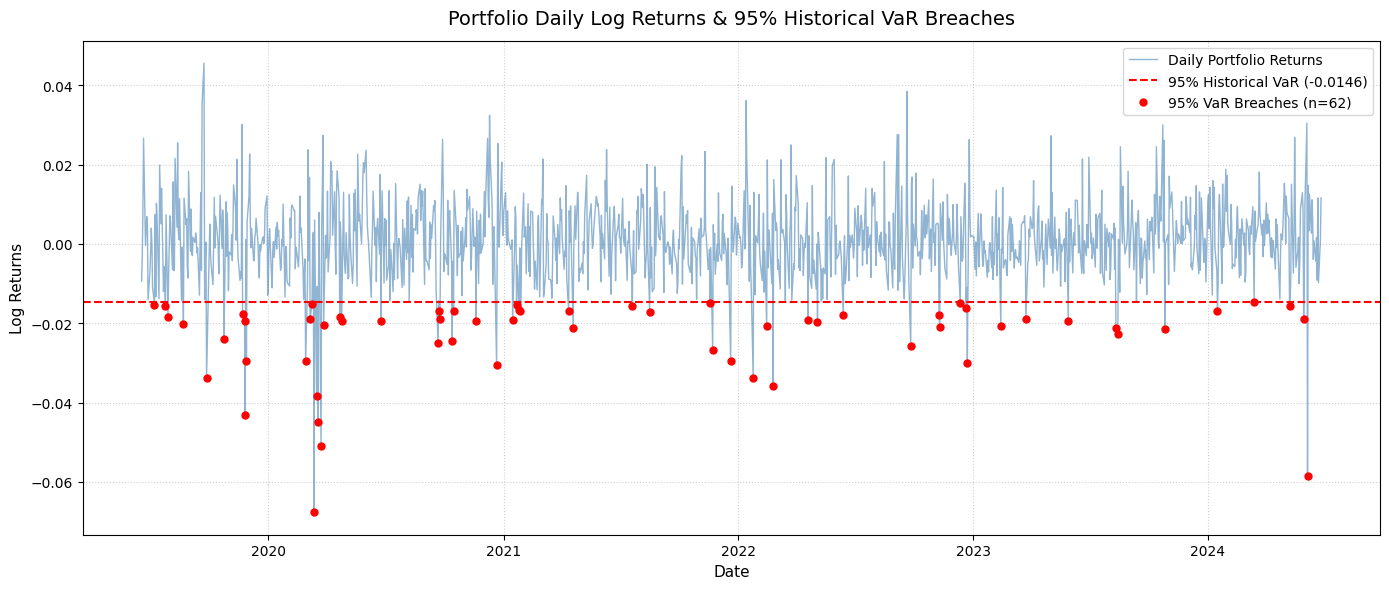

Total Breaches: 62 / 1313 days (4.72% observed vs 5.00% expected)


In [66]:
# --- VaR Breach Visualization ---

# 1. Define the 95% 1-day VaR threshold (expressed as a negative return threshold)
# Uses var_95_mean calculated in Cell [13]
var_threshold_95 = -var_95_mean

# 2. Identify days where returns breached (fell below) the 95% VaR cutoff
breaches = portfolio_returns[portfolio_returns < var_threshold_95]

# 3. Create Plot
plt.figure(figsize=(14, 6))

# Plot daily portfolio returns line
plt.plot(
    portfolio_returns.index,
    portfolio_returns,
    color="steelblue",
    alpha=0.6,
    linewidth=1,
    label="Daily Portfolio Returns",
)

# Horizontal dashed line for 95% VaR limit
plt.axhline(
    y=var_threshold_95,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"95% Historical VaR ({var_threshold_95:.4f})",
)

# Mark breach points with red dots
plt.scatter(
    breaches.index,
    breaches,
    color="red",
    s=25,
    zorder=5,
    label=f"95% VaR Breaches (n={len(breaches)})",
)

# Graph Styling
plt.title(
    "Portfolio Daily Log Returns & 95% Historical VaR Breaches",
    fontsize=14,
    pad=12,
)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Log Returns", fontsize=11)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

# Print breach summary metrics
breach_count = len(breaches)
total_days = len(portfolio_returns)
breach_pct = (breach_count / total_days) * 100

print(
    f"Total Breaches: {breach_count} / {total_days} days ({breach_pct:.2f}% observed vs 5.00% expected)"
)

### Task 5 - Backtesting and Model Validation

In [67]:
from scipy.stats import t, norm, chi2
from statsmodels.stats.diagnostic import acorr_ljungbox

def kupiec_test(violations: int, total_obs: int, p_exceed: float) -> float:
    """
    Kupiec POF test (proportion of failures).
    
    violations   = number of observed exceptions (x)
    total_obs    = number of VaR forecasts (T)
    p_exceed     = expected exception probability (e.g. 0.05 for 95% VaR)
    
    Returns the p‑value of LR = -2[ log L0 – log L1 ] ~ χ²(1).
    """
    x, T = violations, total_obs
    # avoid log(0) by handling edge cases
    term1 = x * np.log(p_exceed / (x / T))             if x > 0 else 0
    term2 = (T - x) * np.log((1 - p_exceed) / ((T - x) / T)) if T - x > 0 else 0
    LR = -2 * (term1 + term2)
    p_value = 1 - chi2.cdf(LR, df=1)
    return round(p_value, 5)


def christoffersen_test(actual_violations, alpha=0.05):
    """
    Christoffersen test for VaR model accuracy.  Checks for independence of violations.

    Args:
        actual_violations: A series of 1s (violations) and 0s (no violations)
        alpha: Significance level.

    Returns:
        p_value: p-value of the test.
    """
    # Calculate the number of violations
    num_violations = actual_violations.sum()

    # Perform Ljung-Box test on indicator series
    test_result = acorr_ljungbox(actual_violations, lags=1, return_df=True)  # Lag of 1 is sufficient for this test
    p_value = test_result['lb_pvalue'][1]
    return p_value

In [68]:
# calculate the number of violations 
# print the acceptable number of violations according to var_95 and var_99
print(f"Acceptable number of violations for 95% VaR: {len(portfolio_returns_df) * 0.05:.2f}")
print(f"Acceptable number of violations for 99% VaR: {len(portfolio_returns_df) * 0.01:.2f}")
violations = (portfolio_returns_df['Portfolio Returns'] < -var_99).astype(int)  # Assuming var_99 is the VaR threshold
violations_ind = violations.astype(int)  # Convert violations to integers for statistical tests
print('Total number of violations:', violations.sum()) 

# Kupiec POF test
p_val_k = kupiec_test(violations.sum(), len(violations), 0.05)
print(f"Kupiec Test p‑value: {p_val_k}")
if(p_val_k < 0.05):
    print("Reject the null hypothesis. Too many violations. The model understates/overstates risk.")
else:
    print("Fail to reject the null hypothesis. Actual number of violations is consistent with expected VaR model.")
# Christoffersen test
p_val_c = christoffersen_test(violations_ind)
print(f"Christoffersen Test p-value: {p_val_c.round(5)}")
if(p_val_c < 0.05):
    print("Reject the null hypothesis. The violations are not independent.")
else:
    print("Fail to reject the null hypothesis. The violations are independent.")

Acceptable number of violations for 95% VaR: 65.65
Acceptable number of violations for 99% VaR: 13.13
Total number of violations: 15
Kupiec Test p‑value: 0.0
Reject the null hypothesis. Too many violations. The model understates/overstates risk.
Christoffersen Test p-value: 0.67482
Fail to reject the null hypothesis. The violations are independent.


In [69]:
import statsmodels.api as sm
import numpy as np

# Assuming 'residuals' from the ARIMA model is available
# Perform the ARCH test for conditional heteroskedasticity
arch_test = sm.stats.diagnostic.acorr_ljungbox(residuals**2, lags=[10], return_df=True) # Test on squared residuals

# Print the test results
print("\nARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):")
print(arch_test)

# Interpretation
alpha = 0.05  # Significance level
if arch_test['lb_pvalue'][10] < alpha:
    print("Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.")
else:
    print("Fail to reject the null hypothesis. Conditional heteroskedasticity is not present in the residuals.")


ARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):
       lb_stat     lb_pvalue
10  144.368396  5.354936e-26
Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.


### Task 5A - Backtesting Helper Functions
Kupiec POF test, Christoffersen independence test and the joint Christoffersen (conditional coverage) test, working directly on a 0/1 breach array.

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
from scipy.stats import chi2
from scipy.special import xlogy

def kupiec_lr(x, T, p):
    """Kupiec proportion-of-failures LR statistic (chi2, 1 dof)."""
    pi = x / T
    ll0 = xlogy(T - x, 1 - p) + xlogy(x, p)
    ll1 = xlogy(T - x, 1 - pi) + xlogy(x, pi)
    return -2 * (ll0 - ll1)

def christoffersen_ind_lr(v):
    """Christoffersen independence LR statistic (chi2, 1 dof) from the 0/1 breach array."""
    v = np.asarray(v).astype(int)
    a, b = v[:-1], v[1:]
    n00 = np.sum((a == 0) & (b == 0)); n01 = np.sum((a == 0) & (b == 1))
    n10 = np.sum((a == 1) & (b == 0)); n11 = np.sum((a == 1) & (b == 1))
    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    ll0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    ll1 = (xlogy(n00, 1 - pi01) + xlogy(n01, pi01) +
           xlogy(n10, 1 - pi11) + xlogy(n11, pi11))
    return -2 * (ll0 - ll1)

def full_backtest(violations, p):
    """Kupiec (POF), Christoffersen (independence) and JOINT Christoffersen (conditional coverage, chi2 2 dof)."""
    v = np.asarray(violations).astype(int)
    x, T = v.sum(), len(v)
    lr_pof = kupiec_lr(x, T, p)
    lr_ind = christoffersen_ind_lr(v)
    lr_cc = lr_pof + lr_ind
    return {
        "Violations": int(x), "Expected": round(T * p, 1), "Rate %": round(100 * x / T, 2),
        "Kupiec p": round(1 - chi2.cdf(lr_pof, 1), 4),
        "Christoffersen IND p": round(1 - chi2.cdf(lr_ind, 1), 4),
        "Joint Christoffersen (CC) p": round(1 - chi2.cdf(lr_cc, 2), 4),
    }

### Task 5B - Rolling Window Backtesting
**Model:** ARIMA(0,0,0) (constant mean) + GARCH(1,1) with Student-t innovations.

For every test day *t*:
1. Build the estimation window D_t = {r(t-W), ..., r(t-1)}
2. Fit the model on D_t to get the parameters, forecast mu_t and sigma_t
3. Simulate 10,000 returns: r_t = mu_t + sigma_t * z_t, where z_t ~ Student-t (captures fat tails)
4. Compute VaR from the simulated distribution
5. If the real return r_t breaches the VaR, store **1**, otherwise **0**

The resulting 0/1 breach array is backtested with the Kupiec test, the Christoffersen independence test and the **joint Christoffersen (conditional coverage) test**.

In [71]:
RW_W        = 250      # window size W  (250 trading days ~ 1 year)
RW_SIMS     = 10000    # simulated returns per day
RW_N_TEST   = None     # None = test on every day after the first window; set = RW_W to test on exactly W days
rw_rng      = np.random.default_rng(42)

rw_rets = portfolio_returns.dropna()
rw_n    = len(rw_rets)
rw_first = RW_W if RW_N_TEST is None else max(RW_W, rw_n - RW_N_TEST)

rw_rows = []
for i in range(rw_first, rw_n):
    D_t = rw_rets.iloc[i - RW_W:i] * 100                      # x100 for numerical stability of the optimiser
    res = arch_model(D_t, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
    fc  = res.forecast(horizon=1)
    mu_t    = fc.mean.iloc[-1, 0] / 100
    sigma_t = np.sqrt(fc.variance.iloc[-1, 0]) / 100
    nu      = max(res.params["nu"], 2.05)                     # t degrees of freedom (must be > 2)

    z_t   = rw_rng.standard_t(nu, RW_SIMS) / np.sqrt(nu / (nu - 2))   # unit-variance fat-tailed shocks
    sim_r = mu_t + sigma_t * z_t                              # r_t = mu_t + sigma_t * z_t

    var95 = -np.percentile(sim_r, 5)
    var99 = -np.percentile(sim_r, 1)
    actual = rw_rets.iloc[i]
    rw_rows.append({
        "Date": rw_rets.index[i], "Actual": actual, "Sim_r_t": sim_r[0], "Sim_mean": sim_r.mean(),
        "VaR95": var95, "VaR99": var99,
        "Breach95": int(actual < -var95), "Breach99": int(actual < -var99),
        "SimBreach95": int(sim_r[0] < -var95), "SimBreach99": int(sim_r[0] < -var99),
    })

rw_df = pd.DataFrame(rw_rows).set_index("Date")
print(f"Rolling-window backtest done: W={RW_W}, test days={len(rw_df)}")
rw_df.head()

Rolling-window backtest done: W=250, test days=1063


,Actual,Sim_r_t,Sim_mean,VaR95,VaR99,Breach95,Breach99,SimBreach95,SimBreach99
Date,,,,,,,,,
2020-06-01,0.023649,0.006244,0.000239,0.024775,0.039793,0,0,0,0
2020-06-02,0.012198,0.024077,0.000069,0.028746,0.047401,0,0,0,0
2020-06-03,0.004704,0.025431,0.000339,0.025526,0.043137,0,0,0,0
2020-06-04,0.001968,-0.003894,0.000201,0.021656,0.034997,0,0,0,0
2020-06-05,-0.000142,0.010465,0.000276,0.018881,0.031786,0,0,0,0


In [72]:
rw_results = pd.DataFrame({
    "95% VaR (rolling)": full_backtest(rw_df["Breach95"], 0.05),
    "99% VaR (rolling)": full_backtest(rw_df["Breach99"], 0.01),
}).T
print("ROLLING WINDOW BACKTEST  (H0 of every test: model is adequate; p < 0.05 => reject)")
rw_results

ROLLING WINDOW BACKTEST  (H0 of every test: model is adequate; p < 0.05 => reject)


,Violations,Expected,Rate %,Kupiec p,Christoffersen IND p,Joint Christoffersen (CC) p
95% VaR (rolling),46.0,53.2,4.33,0.3035,0.4849,0.4615
99% VaR (rolling),13.0,10.6,1.22,0.4802,0.1466,0.2717


### Task 5C - Static vs Rolling Window Comparison
- Static = one fixed full-sample Historical Simulation VaR applied to the same test days (the original static backtest in Task 5 is kept unchanged)
- Both are tested with the correct exception probability: 0.05 for 95% VaR and 0.01 for 99% VaR

STATIC vs ROLLING WINDOW BACKTEST (same test days)


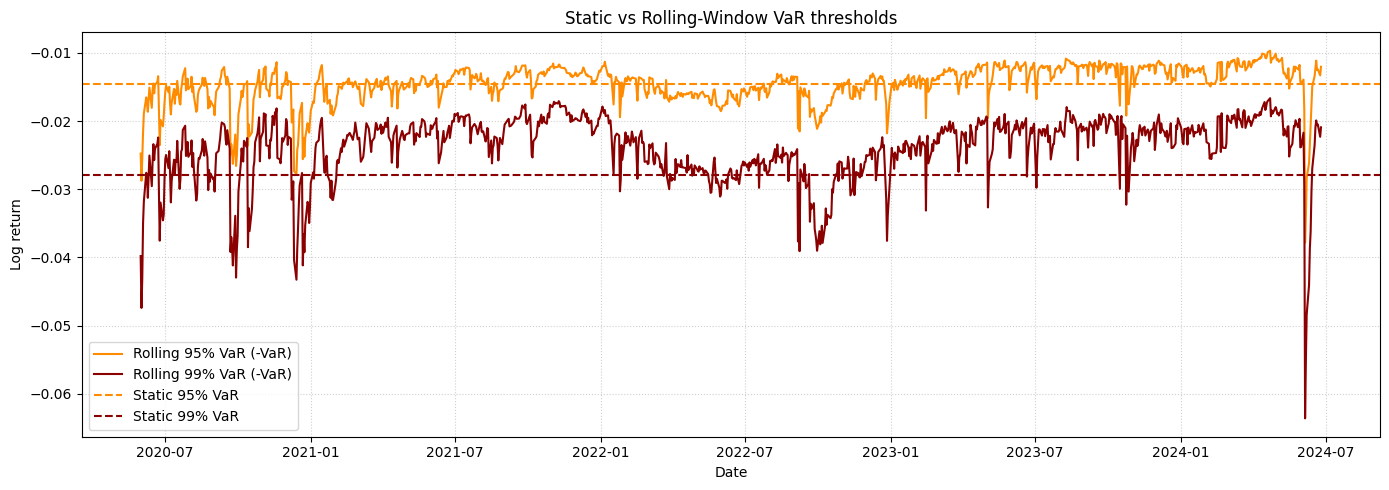

In [73]:
st_breach95 = (rw_df["Actual"] < -var_95_mean).astype(int)
st_breach99 = (rw_df["Actual"] < -var_99_mean).astype(int)

comparison = pd.DataFrame({
    "Static 95%":  full_backtest(st_breach95, 0.05),
    "Rolling 95%": full_backtest(rw_df["Breach95"], 0.05),
    "Static 99%":  full_backtest(st_breach99, 0.01),
    "Rolling 99%": full_backtest(rw_df["Breach99"], 0.01),
}).T
print("STATIC vs ROLLING WINDOW BACKTEST (same test days)")
comparison

# Static vs rolling VaR threshold (line plot)
plt.figure(figsize=(14, 5))
plt.plot(rw_df.index, -rw_df["VaR95"], color="darkorange", label="Rolling 95% VaR (-VaR)")
plt.plot(rw_df.index, -rw_df["VaR99"], color="darkred",    label="Rolling 99% VaR (-VaR)")
plt.axhline(-var_95_mean, color="darkorange", linestyle="--", label="Static 95% VaR")
plt.axhline(-var_99_mean, color="darkred",    linestyle="--", label="Static 99% VaR")
plt.title("Static vs Rolling-Window VaR thresholds")
plt.xlabel("Date"); plt.ylabel("Log return"); plt.grid(True, linestyle=":", alpha=0.6); plt.legend()
plt.tight_layout(); plt.show()

### Task 5D - VaR Breach Plots
- Actual log returns vs simulated r_t
- Actual breaches vs simulated breaches (95% and 99% VaR)

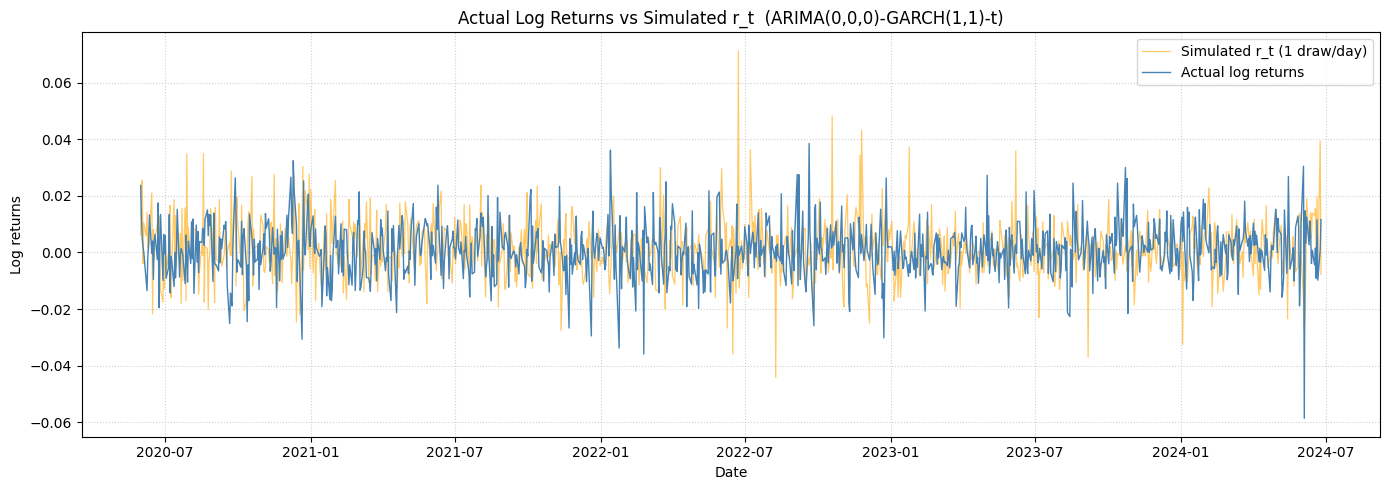

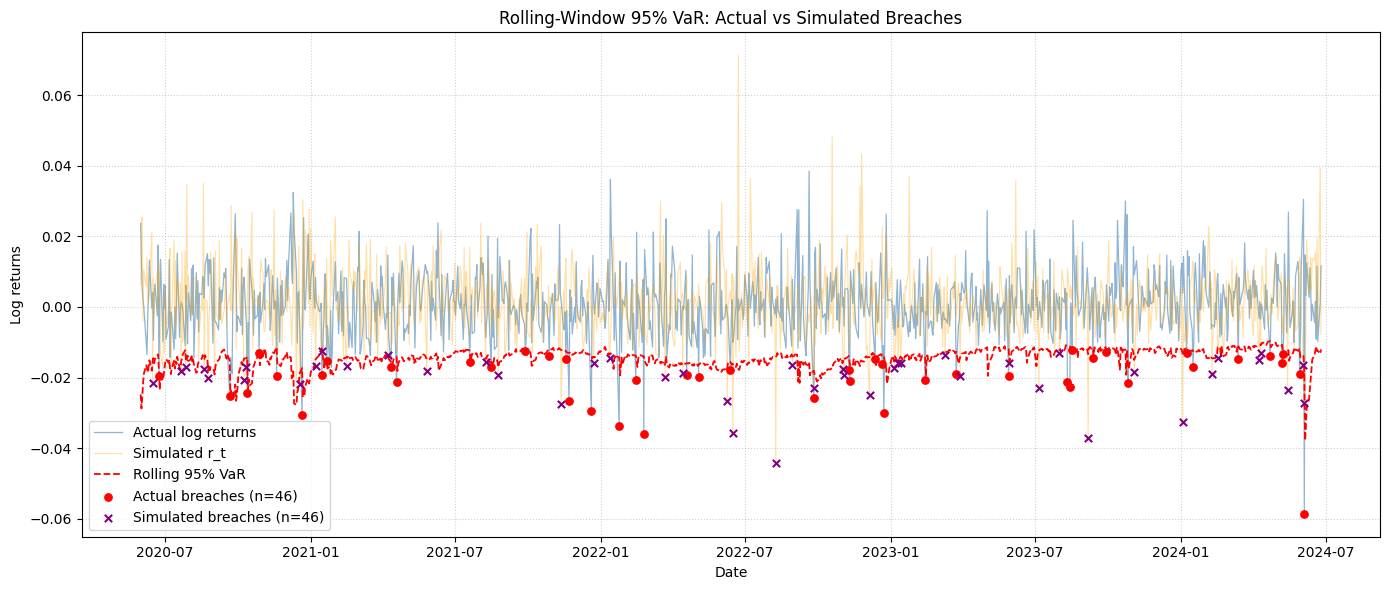

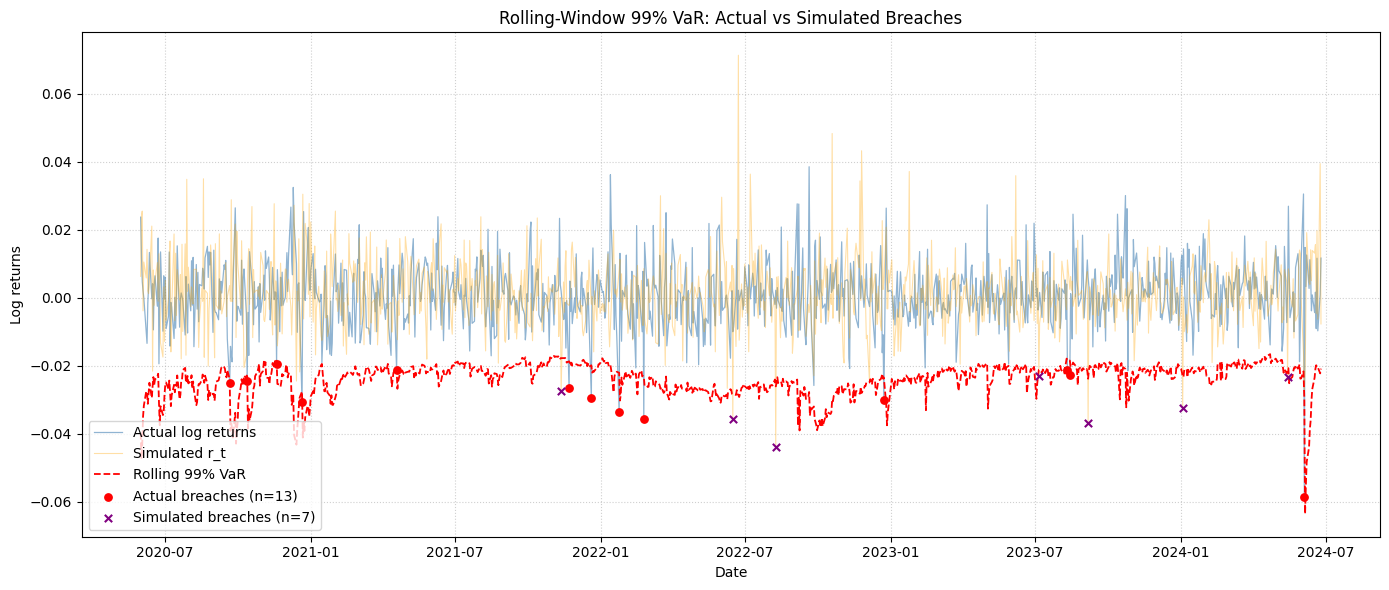

In [74]:
# Plot 1: actual log returns vs simulated r_t
plt.figure(figsize=(14, 5))
plt.plot(rw_df.index, rw_df["Sim_r_t"], color="orange", alpha=0.6, linewidth=0.9, label="Simulated r_t (1 draw/day)")
plt.plot(rw_df.index, rw_df["Actual"],  color="steelblue", linewidth=1.0, label="Actual log returns")
plt.title("Actual Log Returns vs Simulated r_t  (ARIMA(0,0,0)-GARCH(1,1)-t)")
plt.xlabel("Date"); plt.ylabel("Log returns"); plt.grid(True, linestyle=":", alpha=0.6); plt.legend()
plt.tight_layout(); plt.show()

# Plot 2 & 3: breach plots at 95% and 99%
def plot_rw_breaches(level):
    tag = f"{level}"
    var_line = -rw_df[f"VaR{tag}"]
    act_b = rw_df["Actual"][rw_df[f"Breach{tag}"] == 1]
    sim_b = rw_df["Sim_r_t"][rw_df[f"SimBreach{tag}"] == 1]
    plt.figure(figsize=(14, 6))
    plt.plot(rw_df.index, rw_df["Actual"],  color="steelblue", alpha=0.6, linewidth=0.9, label="Actual log returns")
    plt.plot(rw_df.index, rw_df["Sim_r_t"], color="orange",    alpha=0.35, linewidth=0.8, label="Simulated r_t")
    plt.plot(rw_df.index, var_line, color="red", linestyle="--", linewidth=1.3, label=f"Rolling {tag}% VaR")
    plt.scatter(act_b.index, act_b, color="red",    s=28, zorder=5, label=f"Actual breaches (n={len(act_b)})")
    plt.scatter(sim_b.index, sim_b, color="purple", marker="x", s=28, zorder=5, label=f"Simulated breaches (n={len(sim_b)})")
    plt.title(f"Rolling-Window {tag}% VaR: Actual vs Simulated Breaches")
    plt.xlabel("Date"); plt.ylabel("Log returns"); plt.grid(True, linestyle=":", alpha=0.6); plt.legend(loc="lower left")
    plt.tight_layout(); plt.show()

plot_rw_breaches("95")
plot_rw_breaches("99")

### Task 6 : (Option Pricing and Greek Sensitivities)
- Simulated the GBM Stock Prices for SBIN.NS (10,000 simulations) - for Last Thursday of April
- Used GBM paths to compute Call/Put option prices
- Estimate Delta (finite differences), Gamma, Vega, Theta
- Compare the greeks for different strike prices (K) and Maturities (T)

In [75]:
import yfinance as yf
import numpy as np
import pandas as pd
# Task 6 - Option Pricing & Greek Sensitivities
ticker = 'SBIN.NS'  #SBI ticker
# simulate GBM paths for Last Thursday 24/04/25 from 1/01/2024 to 24/04/2025
start_date = '2025-04-01'
end_date = '2025-04-22'
# use these paths to compute European call/put option prices and Greeks
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
data = data.ffill().dropna()
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data

[*********************100%***********************]  1 of 1 completed


Ticker,Date,SBIN.NS
0,2025-04-01,743.114929
1,2025-04-02,747.207520
2,2025-04-03,750.337097
3,2025-04-04,739.022339
4,2025-04-07,719.233582
5,2025-04-08,740.129761
6,2025-04-09,714.707703
7,2025-04-11,725.926086
8,2025-04-15,735.218628
9,2025-04-16,743.163086


In [76]:
import random
import math
def simulate_gbm(S0, mu, sigma, T, N):
    dt = T / N  # Time step
    prices = [S0]  # List to store the stock prices, starting with the initial price
    for i in range(1, N):
        Z = random.gauss(0, 1)  # Generate a random number from a standard normal distribution
        price = prices[i-1] * math.exp((mu - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z)
        prices.append(price)
    return prices

# Function to simulate multiple paths
def simulate_multiple_paths(S0, mu, sigma, T, N, M):
    all_prices = []  # List to store multiple simulated paths
    for i in range(M):
        all_prices.append(simulate_gbm(S0, mu, sigma, T, N))  # Simulate each path
    return all_prices

# Function to visualize the simulated stock price paths
def plot_simulation_paths(all_prices):
    plt.figure(figsize=(10, 6))
    for path in all_prices:
        plt.plot(path, color='blue', alpha=0.1)  # Simulate multiple paths
    plt.title('SIMULATED GBM PATHS FOR SBIN')
    plt.xlabel('Time Steps')
    plt.ylabel('Stock Price')
    plt.show()

In [77]:
stock_data = yf.download('SBIN.NS', start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
S0 = 1252.6 # 1/04/2025 Stock Price
returns = np.log(stock_data / stock_data.shift(1)).dropna()
mean_returns_SBIN = returns.mean()*252
print("Mean Returns : ",mean_returns_SBIN)
mean_std_SBIN = returns.std()*np.sqrt(252)
print("Standard Deviation : ",mean_std_SBIN)

[*********************100%***********************]  1 of 1 completed


Mean Returns :  Ticker
SBIN.NS    1.298395
dtype: float64
Standard Deviation :  Ticker
SBIN.NS    0.352362
dtype: float64


In [78]:
# GBM path simulator for stock
def simulate_gbm_paths(S0, mu, sigma, T, N, M, seed=None):
    """
    Simulate M GBM paths, each with N time-steps, over total horizon T (in years).
    Returns an (M, N+1) array of prices including S0 at t=0.
    """
    dt = T / N
    if seed is not None:
        np.random.seed(seed)
    # Standard normals: shape (M, N)
    Z = np.random.normal(size=(M, N))
    # Pre-allocate and set initial prices
    S = np.zeros((M, N+1))
    S[:, 0] = S0
    # Step forward
    for t in range(1, N+1):
        S[:, t] = S[:, t-1] * np.exp((mu - 0.5*sigma**2)*dt
                                       + sigma * np.sqrt(dt) * Z[:, t-1])
    return S
# Finding option prices
def price_european_call(S_paths, K, r, T):
    payoffs = np.maximum(S_paths[:, -1] - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)
def price_european_put(S_paths, K, r, T):
    payoffs = np.maximum(K-S_paths[:,-1],0)
    return np.exp(-r * T) * np.mean(payoffs)
# Option Greeks
def delta_fd(base_price_fn, bump):
    C0_call, _ = base_price_fn()
    C_plus_call, _ = base_price_fn(S0_bump=+bump)
    return (C_plus_call - C0_call) / bump

def gamma_fd(base_price_fn, bump):
    C_minus,_ = base_price_fn(S0_bump=-bump)
    C0_call,_      = base_price_fn()
    C_plus,_  = base_price_fn(S0_bump=+bump)
    return (C_plus - 2*C0_call + C_minus) / bump**2

def vega_fd(base_price_fn, bump):
    C_plus,_  = base_price_fn(sigma_bump=+bump)
    C_minus,_ = base_price_fn(sigma_bump=-bump)
    return (C_plus - C_minus) / (2*bump)

def theta_fd(base_price_fn, dt):
    # Theta ≈ (C(T - dt) - C(T)) / dt
    C_now,_    = base_price_fn()
    C_earlier,_ = base_price_fn(T_bump=-dt)
    return (C_earlier - C_now) / dt

def make_pricer(S0, mu, sigma, r, K, T, N, M, seed=42):
    def pricer(S0_bump=0.0, sigma_bump=0.0, T_bump=0.0):
        # adjust parameters
        S0_adj   = S0   + S0_bump
        sigma_adj= sigma+ sigma_bump
        T_adj    = T    + T_bump
        # If T changes, adjust N accordingly so dt=1/252
        N_adj    = int(np.round(T_adj * 252))
        paths = simulate_gbm_paths(S0_adj, mu, sigma_adj, T_adj, N_adj, M, seed)
        return price_european_call(paths, K, r, T_adj), price_european_put(paths, K, r, T_adj)
    return pricer

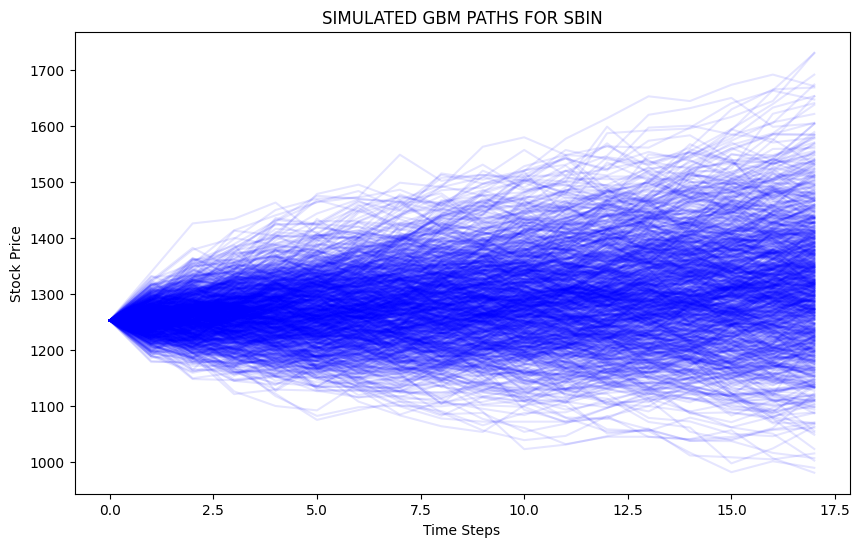

In [79]:
if __name__ == "__main__":
    
    mu = 0.771472             # mean returns (drift)
    sigma = 0.34068           # using mean standard deviation
    S0    = 1252.6            # stock price on 1-Apr-2025
    r     = 0.06              # annual risk-free rate
    # 18 trading days from 1 Apr to 24 Apr => T_full = 18/252
    N_full = 18
    T_full = N_full / 252
    M = 1000 # number of paths
    
    simulated_paths = simulate_multiple_paths(S0, mu, sigma, T_full, N_full, M)
    plot_simulation_paths(simulated_paths)
    
    # Strikes: 90%, 100%, 110% (for comparison across different strike prices)
    strikes = [0.9*S0, S0, 1.1*S0]

    # Maturities (for comparison across different maturities)
    maturity_steps = [N_full//3, 2*(N_full//3), N_full]
    maturities     = [n/252 for n in maturity_steps]

    seed = 42   # for reproducibility

    # Collect results
    results = []

    for T, step in zip(maturities, maturity_steps):
        N = step
        dt = 1/252
        for K in strikes:
            # Create a pricer closure for this (K, T)
            pricer = make_pricer(S0, mu, sigma, r, K, T, N, M, seed)

            # Base price
            C0_call, C0_put = pricer()

            # Greeks
            dS    = S0 * 1e-2     # 1% bump
            dsig  = sigma * 1e-2  # 1% vol bump
            Δ     = delta_fd(pricer, dS)
            Γ     = gamma_fd(pricer, dS)
            Vega  = vega_fd(pricer, dsig)
            Θ     = theta_fd(pricer, dt)

            results.append({
                'Maturity (days)':   N,
                'Strike':            K,
                'Price (Call)':             C0_call,
                'Price (Put)':              C0_put,
                'Delta':             Δ,
                'Gamma':             Γ,
                'Vega':              Vega,
                'Theta':             Θ,
            })

In [80]:
# Print a summary table
print("\n Option Prices and Greeks:")
print("\n Strike Prices used = [1127.34, 1252.60, 1377.86]")
print("\n Maturity Days = [6, 12, 18]")
df = pd.DataFrame(results)
df


 Option Prices and Greeks:

 Strike Prices used = [1127.34, 1252.60, 1377.86]

 Maturity Days = [6, 12, 18]


,Maturity (days),Strike,Price (Call),Price (Put),Delta,Gamma,Vega,Theta
0,6,1127.34,147.829546,0.166833,1.009028,0.000196,2.505796,-632.776336
1,6,1252.60,38.243962,15.662434,0.700626,0.007493,69.195025,-695.713242
2,6,1377.86,2.067405,104.567062,0.081268,0.001759,24.960765,-232.048675
3,12,1127.34,170.158326,0.820832,1.012757,0.000659,6.886502,-857.113592
4,12,1252.60,62.330874,17.896005,0.748181,0.003746,87.242865,-840.290463
5,12,1377.86,10.644945,91.112701,0.244643,0.003542,77.542592,-568.971314
6,18,1127.34,198.954121,1.340832,1.027028,0.000654,27.874127,-1307.598617
7,18,1252.60,91.279613,18.390644,0.811491,0.002776,113.672165,-1435.674802
8,18,1377.86,26.511928,78.347279,0.394205,0.004695,130.097915,-839.544383


### Task 7 : Hedging Strategy Implementation (Delta-Neutral)
- Used the Delta-Neutral strategy to rebalance the portfolio weights dynamically across the period of 5 years
- Assumed initial weights to be equal (0.2 for 5 instruments = 1.0)
- Delta for Stocks and NIFTY = 1
- Delta for Exchange Rate = -1
- Delta for Commodity = 0.5
- Displayed the summary statistics for the Delta-Neutral Portfolio
Normalized Portfolio delta is hence - 0.5 ((1 + 1 - 1 + 1 + 0.5)/5)

FIX 2 (look-ahead removed): the weights used on day t are chosen ONLY from information up to day t-1
(trailing LOOKBACK-day mean return). The old version maximised the SAME day's realised return, which
is look-ahead bias and made the hedged portfolio look unrealistically good.

Date: 2019-06-18 00:00:00
Old Weights: [0.2 0.2 0.2 0.2 0.2]
New Weights: [0.1167 0.1167 0.45   0.1167 0.2   ]
Old Portfolio Delta: 0.50000
New Portfolio Delta: -0.00000
--------------------------------------------------
Date: 2019-11-04 00:00:00
Old Weights: [0.2 0.2 0.2 0.2 0.2]
New Weights: [ 0.5  0.   0.5  0.  -0. ]
Old Portfolio Delta: 0.50000
New Portfolio Delta: 0.00000
--------------------------------------------------
Date: 2020-03-23 00:00:00
Old Weights: [0.2 0.2 0.2 0.2 0.2]
New Weights: [0.    0.    0.375 0.125 0.5  ]
Old Portfolio Delta: 0.50000
New Portfolio Delta: -0.00000
--------------------------------------------------
Date: 2020-08-10 00:00:00
Old Weights: [0.2 0.2 0.2 0.2 0.2]
New Weights: [ 0.   0.5  0.5  0.  -0. ]
Old Portfolio Delta: 0.50000
New Portfolio Delta: 0.00000
--------------------------------------------------
Date: 2020-12-25 00:00:00
Old Weights: [0.2 0.2 0.2 0.2 0.2]
New Weights: [ 0.5 -0.   0.5  0.   0. ]
Old Portfolio Delta: 0.50000
New Portfolio

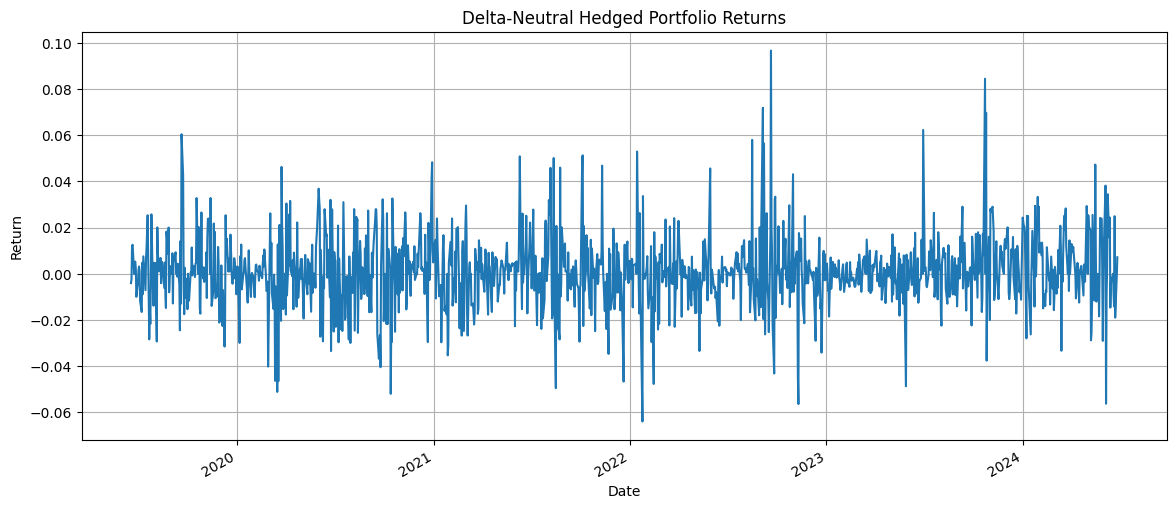

Summary Statistics of Delta-Neutral Hedged Portfolio:
Mean: 0.00113
Std Dev: 0.01556
Skewness: 0.45
Kurtosis: 3.65


In [81]:
# Task - 7 Implementing Hedging Strategies - DELTA - NEUTRAL PORTFOLIO
# (column order now matches delta_vector thanks to FIX 1: HDFC, NIFTY, EURINR, MACPOWER, GOLD)

from scipy.optimize import minimize, linprog

delta_vector = np.array([1, 1, -1, 1, 0.5])  

# Normalize the delta exposures so they represent relative sensitivities
normalized_delta = delta_vector / np.sum(np.abs(delta_vector))

LOOKBACK = 60      # trailing days used to estimate expected returns (past data only)
MIN_OBS  = 20      # before this many past days exist, use the warm-up weights
MAX_W    = 0.5     # max weight in a single asset (keeps solution from being 100% in one asset)

A_eq   = np.vstack([delta_vector, np.ones(len(delta_vector))])   # delta-neutral AND fully invested
b_eq   = np.array([0.0, 1.0])
bounds = [(0, MAX_W)] * len(delta_vector)                         # no shorting

# Warm-up weights: the delta-neutral, fully-invested point closest to equal weights
equal_w = np.array([1/5.0] * 5)
warm = minimize(lambda w: np.sum((w - equal_w) ** 2), equal_w, bounds=bounds,
                constraints=[{'type': 'eq', 'fun': lambda w: np.dot(w, delta_vector)},
                             {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}])
warm_w = warm.x if warm.success else equal_w

# Prepare a container for rebalanced weights
rebalanced_weights = []
prev_w = warm_w
dates = returns_df.index
for i in range(len(dates)):
    if i < MIN_OBS:
        w_new = warm_w
    else:
        # expected return estimated from PAST returns only: rows [i-LOOKBACK, i-1]  (row i excluded!)
        mu_hat = returns_df.iloc[max(0, i - LOOKBACK):i].mean().values
        res = linprog(-mu_hat, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")  # maximise expected return
        w_new = res.x if res.success else prev_w   # fallback: keep yesterday's weights

    rebalanced_weights.append(w_new)

    # Calculate old and new portfolio deltas
    old_delta = np.dot(equal_w, delta_vector)
    new_delta = np.dot(w_new, delta_vector)

    # Print the results (every 100th day to keep output readable)
    if i % 100 == 0:
        print(f"Date: {dates[i]}")
        print(f"Old Weights: {equal_w}")
        print(f"New Weights: {np.round(w_new, 4)}")
        print(f"Old Portfolio Delta: {old_delta:.5f}")
        print(f"New Portfolio Delta: {new_delta:.5f}")
        print("-" * 50)
    prev_w = w_new

# Convert to DataFrame for visualization
rebalanced_weights_df = pd.DataFrame(rebalanced_weights, columns=returns_df.columns, index=dates)

# Compute new portfolio returns using delta-neutral weights
delta_neutral_returns = (returns_df * rebalanced_weights_df).sum(axis=1)

# Plot the delta-neutral portfolio returns
delta_neutral_returns.plot(figsize=(14, 6), title="Delta-Neutral Hedged Portfolio Returns")
plt.ylabel("Return")
plt.grid(True)
plt.show()

# Summary statistics
print("Summary Statistics of Delta-Neutral Hedged Portfolio:")
print(f"Mean: {delta_neutral_returns.mean():.5f}")
print(f"Std Dev: {delta_neutral_returns.std():.5f}")
print(f"Skewness: {skew(delta_neutral_returns):.2f}")
print(f"Kurtosis: {kurtosis(delta_neutral_returns):.2f}")

### Task 7B - Growth of Rs.1: Standard vs Delta-Neutral vs Risk-free
Value of Rs.1 invested in the equal-weight (0.2 each) portfolio, the delta-neutral portfolio and the risk-free asset (6%).

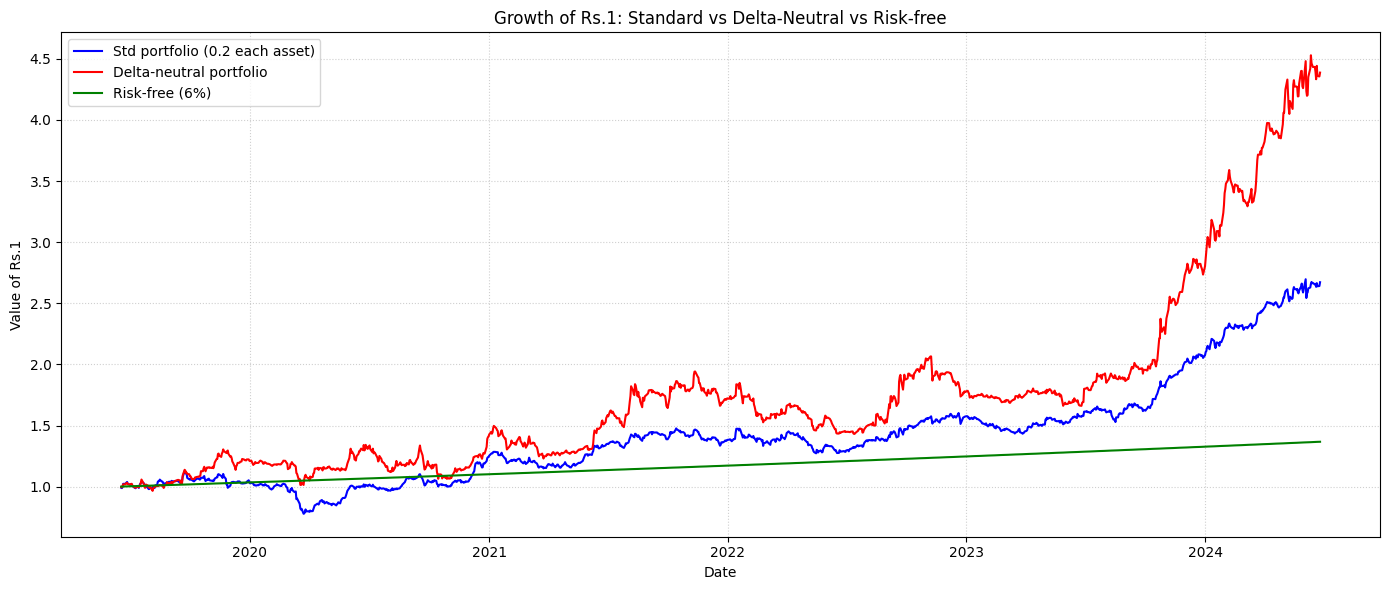

In [82]:
bt_idx   = portfolio_returns.index
RF_ANN   = 0.06                                               # risk-free rate (same as r used in Task 6)
bt_rf    = pd.Series(np.exp(RF_ANN * np.arange(1, len(bt_idx) + 1) / 252), index=bt_idx)
bt_std   = np.exp(portfolio_returns.cumsum())                 # Rs.1 in equal-weight (0.2 each) portfolio
bt_dn    = np.exp(delta_neutral_returns.reindex(bt_idx).fillna(0).cumsum())

plt.figure(figsize=(14, 6))
plt.plot(bt_idx, bt_std, color="blue",  label="Std portfolio (0.2 each asset)")
plt.plot(bt_idx, bt_dn,  color="red",   label="Delta-neutral portfolio")
plt.plot(bt_idx, bt_rf,  color="green", label="Risk-free (6%)")
plt.title("Growth of Rs.1: Standard vs Delta-Neutral vs Risk-free")
plt.xlabel("Date"); plt.ylabel("Value of Rs.1"); plt.grid(True, linestyle=":", alpha=0.6); plt.legend()
plt.tight_layout(); plt.show()

### Task 7C - Option Overlay Strategy (Portfolio + SBI Options)
**Approach** (no look-ahead; decisions use data up to the close of the day the option is bought):
- Hold the 5-asset 0.2-weight portfolio (HDFC AMC is one of the legs)
- Every 21 trading days buy an at-the-money 21-day SBI option, notional = 20% of current wealth (the HDFC weight)
  - SBI trailing 21-day return < 0: buy a **put** (hedge the downside)
  - SBI trailing 21-day return >= 0: buy a **call** (leverage the upside)
- Options are priced by Monte Carlo under risk-neutral GBM (antithetic variates, fixed seed), sigma = rolling 21-day SBI volatility
- Marked to market daily, with the premium cost paid out of portfolio wealth
- Output: volatility before vs after, final value of Rs.1, and the growth plot (blue = standard, green = risk-free, yellow = new strategy)

In [83]:
ov_start = str(bt_idx[0].date())
ov_end   = str((bt_idx[-1] + pd.Timedelta(days=1)).date())
ov_raw   = yf.download("SBIN.NS", start=ov_start, end=ov_end, auto_adjust=False)["Adj Close"]
if isinstance(ov_raw, pd.DataFrame):
    ov_raw = ov_raw.iloc[:, 0]
ov_raw.index = pd.to_datetime(ov_raw.index).tz_localize(None).normalize()
ov_px  = ov_raw.reindex(pd.to_datetime(bt_idx).normalize()).ffill().bfill()
ov_px.index = bt_idx
ov_lr  = np.log(ov_px / ov_px.shift(1))
ov_vol = (ov_lr.rolling(21).std() * np.sqrt(252)).bfill().clip(lower=0.10)
ov_mom = ov_px / ov_px.shift(21) - 1

OV_CYCLE    = 21        # option life / roll period (trading days)
OV_NOTIONAL = 0.20      # fraction of wealth hedged / levered through options
OV_COST     = 0.01      # 1% of premium as transaction cost
OV_R        = 0.06

ov_Z = np.random.default_rng(7).standard_normal(20000)
ov_Z = np.concatenate([ov_Z, -ov_Z])                          # antithetic variates

def mc_option(kind, S, K, T, sig, r=OV_R):
    if T <= 0:
        return max(S - K, 0.0) if kind == "call" else max(K - S, 0.0)
    ST = S * np.exp((r - 0.5 * sig**2) * T + sig * np.sqrt(T) * ov_Z)
    pay = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    return np.exp(-r * T) * pay.mean()

ov_base = portfolio_returns.values
ov_n    = len(ov_base)
ov_V    = np.ones(ov_n + 1)                                   # wealth path of the new strategy (ov_V[0]=1)
ov_pos  = None
ov_kinds = []

for i in range(ov_n):
    # 1) base portfolio P&L
    V_prev = ov_V[i]
    V_new  = V_prev * np.exp(ov_base[i])
    # 2) option overlay P&L (mark-to-market)
    if ov_pos is not None:
        T_rem = max((ov_pos["exp"] - i) / 252, 0)
        O_now = mc_option(ov_pos["kind"], ov_px.iloc[i], ov_pos["K"], T_rem, ov_vol.iloc[i])
        V_new += ov_pos["n"] * (O_now - ov_pos["prev"])
        ov_pos["prev"] = O_now
    ov_V[i + 1] = V_new
    # 3) roll / open a new option at the close of day i (needs 21 days of SBI history)
    if i >= OV_CYCLE and (ov_pos is None or i >= ov_pos["exp"]):
        kind = "put" if ov_mom.iloc[i] < 0 else "call"
        S_i, sig_i = ov_px.iloc[i], ov_vol.iloc[i]
        prem = mc_option(kind, S_i, S_i, OV_CYCLE / 252, sig_i)
        n_opt = OV_NOTIONAL * V_new / S_i
        ov_V[i + 1] -= OV_COST * prem * n_opt
        ov_pos = {"kind": kind, "K": S_i, "n": n_opt, "prev": prem, "exp": i + OV_CYCLE}
        ov_kinds.append((bt_idx[i], kind))

bt_new = pd.Series(ov_V[1:], index=bt_idx)
new_ret = np.log(bt_new / bt_new.shift(1)).fillna(0)

[*********************100%***********************]  1 of 1 completed


APPROACH USED: 5-asset 0.2-weight portfolio + rolling 21-day ATM SBI option overlay (PUT if SBI 21d momentum < 0 to hedge, CALL otherwise to leverage), notional = 20% of wealth, Monte-Carlo GBM pricing, daily mark-to-market, 1% premium cost.
#puts bought: 24 | #calls bought: 38
Volatility did NOT decrease: 0.1627 -> 0.1694  (+4.11%)
Final value of Rs.1 higher than std portfolio? True


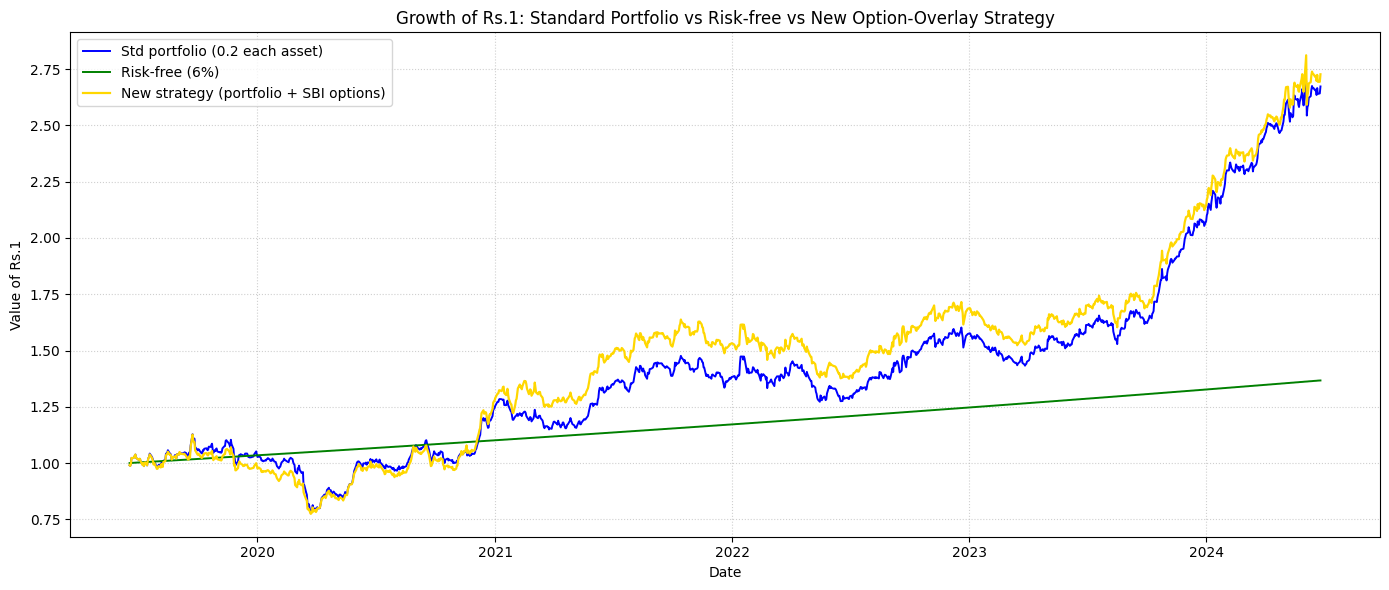

In [84]:
def ann_vol(x):  return x.std() * np.sqrt(252)
def max_dd(w):   return ((w / w.cummax()) - 1).min()
def sharpe(x):   return (x.mean() * 252 - OV_R) / (x.std() * np.sqrt(252))

summary = pd.DataFrame({
    "Std portfolio (0.2 each)": [ann_vol(portfolio_returns), bt_std.iloc[-1], max_dd(bt_std), sharpe(portfolio_returns)],
    "New: portfolio + SBI options": [ann_vol(new_ret), bt_new.iloc[-1], max_dd(bt_new), sharpe(new_ret)],
}, index=["Annualised volatility", "Final value of Rs.1", "Max drawdown", "Sharpe ratio"]).T
print("APPROACH USED: 5-asset 0.2-weight portfolio + rolling 21-day ATM SBI option overlay "
      "(PUT if SBI 21d momentum < 0 to hedge, CALL otherwise to leverage), notional = 20% of wealth, "
      "Monte-Carlo GBM pricing, daily mark-to-market, 1% premium cost.")
print(f"#puts bought: {sum(k == 'put' for _, k in ov_kinds)} | #calls bought: {sum(k == 'call' for _, k in ov_kinds)}")
vol_old, vol_new = ann_vol(portfolio_returns), ann_vol(new_ret)
change = 100 * (vol_new - vol_old) / vol_old
if vol_new < vol_old:
    print(f"Volatility DECREASED: {vol_old:.4f} -> {vol_new:.4f}  ({change:.2f}%)")
else:
    print(f"Volatility did NOT decrease: {vol_old:.4f} -> {vol_new:.4f}  ({change:+.2f}%)")
print("Final value of Rs.1 higher than std portfolio?", bt_new.iloc[-1] > bt_std.iloc[-1])
summary

# Plot 2: growth of Rs.1  (blue = std, green = risk-free, yellow = new strategy)
plt.figure(figsize=(14, 6))
plt.plot(bt_idx, bt_std, color="blue",  linewidth=1.4, label="Std portfolio (0.2 each asset)")
plt.plot(bt_idx, bt_rf,  color="green", linewidth=1.4, label="Risk-free (6%)")
plt.plot(bt_idx, bt_new, color="gold",  linewidth=1.6, label="New strategy (portfolio + SBI options)")
plt.title("Growth of Rs.1: Standard Portfolio vs Risk-free vs New Option-Overlay Strategy")
plt.xlabel("Date"); plt.ylabel("Value of Rs.1"); plt.grid(True, linestyle=":", alpha=0.6); plt.legend()
plt.tight_layout(); plt.show()